In [1]:
# Level 3 - Task 1: Random Forest Classifier

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load Iris Dataset

iris = load_iris()

X = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

y = pd.Series(iris.target, name="target")

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

print("\nDataset Shape:", X.shape)
print("Number of Classes:", len(iris.target_names))
print("Classes:", iris.target_names)

Features:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Target:
0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64

Dataset Shape: (150, 4)
Number of Classes: 3
Classes: ['setosa' 'versicolor' 'virginica']


In [3]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (120, 4)
Testing data: (30, 4)


In [4]:
# Create and Train Random Forest Classifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [6]:
# Make predictions on test data

y_pred = rf_model.predict(X_test)

print("Predictions:")
print(y_pred)

Predictions:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 1 0 2 1 1 2 2 1 0 2 0]


In [7]:
# Calculate Evaluation Metrics

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print("Model Evaluation")
print("-----------------")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

Model Evaluation
-----------------
Accuracy  : 0.9000
Precision : 0.9024
Recall    : 0.9000
F1-Score  : 0.8997


In [8]:
# Classification Report

print("Classification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=iris.target_names
))

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



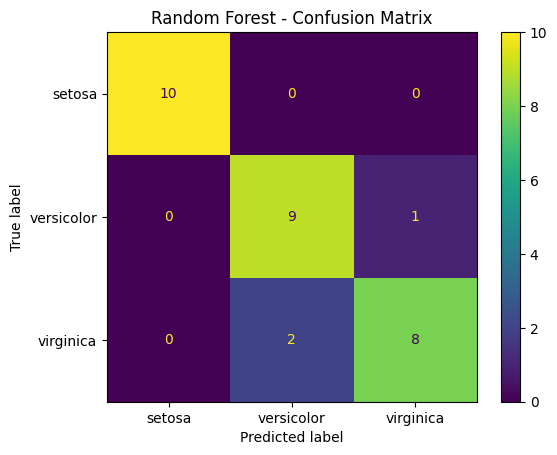

In [9]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
)

disp.plot()
plt.title("Random Forest - Confusion Matrix")
plt.show()

In [10]:
# Hyperparameter Tuning using GridSearchCV

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(f"{grid_search.best_score_:.4f}")

Best Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}

Best Cross-Validation Accuracy:
0.9500


In [11]:
# Get the Best Random Forest Model

best_rf_model = grid_search.best_estimator_

print("Best Random Forest Model:")
print(best_rf_model)

Best Random Forest Model:
RandomForestClassifier(n_estimators=50, random_state=42)


In [12]:
# Predictions using the Best Random Forest Model

best_y_pred = best_rf_model.predict(X_test)

accuracy = accuracy_score(y_test, best_y_pred)
precision = precision_score(y_test, best_y_pred, average="weighted")
recall = recall_score(y_test, best_y_pred, average="weighted")
f1 = f1_score(y_test, best_y_pred, average="weighted")

print("Best Model Evaluation")
print("---------------------")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

Best Model Evaluation
---------------------
Accuracy  : 0.9000
Precision : 0.9024
Recall    : 0.9000
F1-Score  : 0.8997


In [13]:
# 5-Fold Cross-Validation

cv_scores = cross_val_score(
    best_rf_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross-Validation Scores:")
print(cv_scores)

print(f"\nMean Cross-Validation Accuracy: {cv_scores.mean():.4f}")

Cross-Validation Scores:
[0.96666667 0.96666667 0.93333333 0.96666667 1.        ]

Mean Cross-Validation Accuracy: 0.9667


In [14]:
# Feature Importance

feature_importance = pd.Series(
    best_rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Feature Importance:")
print(feature_importance)

Feature Importance:
petal width (cm)     0.440371
petal length (cm)    0.430601
sepal length (cm)    0.114760
sepal width (cm)     0.014267
dtype: float64


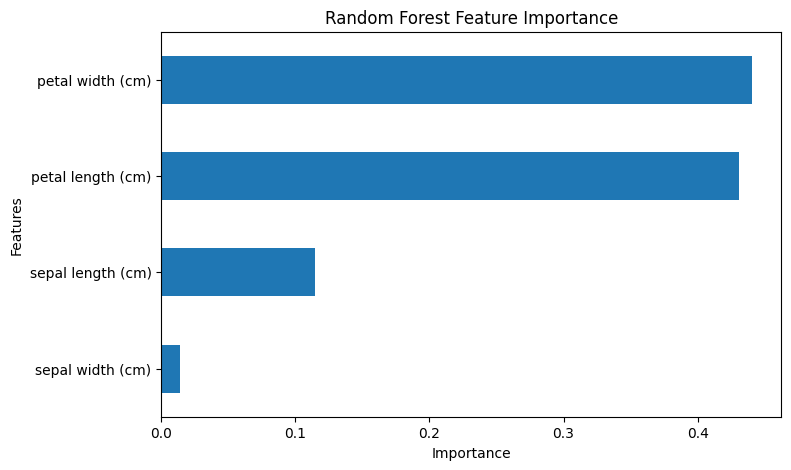

In [15]:
# Plot Feature Importance

plt.figure(figsize=(8, 5))

feature_importance.sort_values().plot(kind="barh")

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Random Forest Feature Importance")
plt.show()